In [1]:
import numpy as np
import wandb
import gymnasium as gym

from morl_baselines.multi_policy.morld.morld import MORLD
from env import MyFourRoom
from utils.visualize_front import visualize_front_general
from wrappers import CombineWrapper

from utils.config import TOTAL_TIMESTEPS, MAX_EPISODE_LENGTH, EXPERIMENT_NAME
from utils.eval import eval_full_four_room

Weights: [[0.         0.         0.         1.        ]
 [0.         0.         1.         0.        ]
 [0.         0.37862915 0.24462117 0.37674968]
 [0.         1.         0.         0.        ]
 [0.5009124  0.         0.4990876  0.        ]
 [1.         0.         0.         0.        ]]
Neighborhoods: [[2], [4], [3], [2], [5], [4]]


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: kristofs (kristofs-ai) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:134: UserWarning: WARN: The obs returned by the `reset()` method was expecting numpy array dtype to be <class 'numpy.float32'>, actual type: int32
  logger.warn(
c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")
c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:245: UserWarning: WARN: The reward returned by `step()` must be a float, int, np.integer or np.floating, actual type: <class 'numpy.ndarray'>
  logger.warn(


Starting training...
Current pareto archive:
[array([0.47186859, 0.58831825, 0.43325765, 0.70889347]), array([0.86730241, 0.62517574, 0.55205181, 0.35267256]), array([0.59008549, 0.35365372, 0.66654007, 0.66594901]), array([0.43305667, 0.51304383, 0.428342  , 1.4918644 ]), array([0.51265077, 0.70693014, 0.7057549 , 0.43344285]), array([0.3905122 , 0.74711629, 0.86394814, 0.51206167])]
[]


c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:134: UserWarning: WARN: The obs returned by the `step()` method was expecting numpy array dtype to be <class 'numpy.float32'>, actual type: int32
  logger.warn(
c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `step()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")
c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:245: UserWarning: WARN: The reward returned by `step()` must be a float, int, np.integer or np.floating, actual type: <class 'numpy.ndarray'>
  logger.warn(


Switching... global_steps: 40000
Updating other policies...
Current pareto archive:
[array([0.47186859, 0.58831825, 0.43325765, 0.70889347]), array([0.86730241, 0.62517574, 0.55205181, 0.35267256]), array([0.59008549, 0.35365372, 0.66654007, 0.66594901]), array([0.43305667, 0.51304383, 0.428342  , 1.4918644 ]), array([0.51265077, 0.70693014, 0.7057549 , 0.43344285]), array([0.3905122 , 0.74711629, 0.86394814, 0.51206167]), array([0.079401  , 0.27367348, 0.11801593, 2.31856884]), array([0.86472933, 0.5102954 , 0.62497283, 0.51010428]), array([0.51147358, 0.54931618, 0.35287251, 1.06273532]), array([0.78672123, 0.47206367, 0.62752228, 0.66850142]), array([0.78672028, 0.78532436, 0.66397686, 0.58871032])]
[]
Global step: 40000
Save freq: 10000
Saving checkpoint at step 40000
Saving population...
Saving archive...
Switching... global_steps: 80000
Updating other policies...
Current pareto archive:
[array([0.47186859, 0.58831825, 0.43325765, 0.70889347]), array([0.86730241, 0.62517574, 0.552

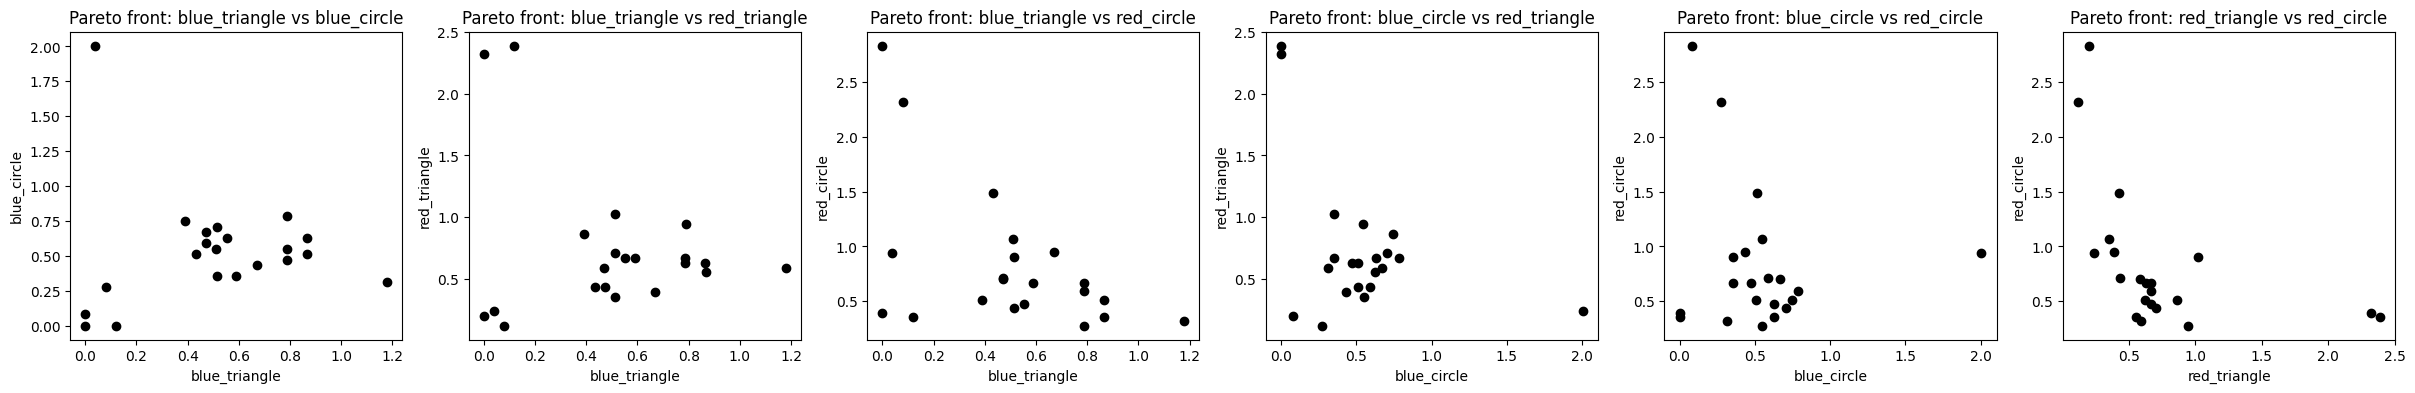

charts/SPS,█▇▅▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
eval/cardinality,▁▃▆█
eval/eum,▁▃▆█
eval/hypervolume,▁▄▇█
eval_0/discounted_vec_0,▂▁▂▁█▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁
eval_0/discounted_vec_1,▃█▁▂▃▃▁▂▃▂▁▃▁▁▁▁▁▁▁▁
eval_0/discounted_vec_2,▄▆▆▅▃▁▁▃▄▁▃█▁▁▁▁▁▁▁▁
eval_0/discounted_vec_3,▂▂▅▃▁▆▆▄▅▇█▅▆██▆▅▇▆▆
eval_0/scalarized_discounted_return,▂▂▅▃▁▆▆▄▅▇█▅▆██▆▅▇▆▆
eval_0/scalarized_return,▂▂▅▃▁▆▆▄▆▇█▅▆██▆▅▇▆▆
+79,...


In [2]:
env = gym.wrappers.TimeLimit(gym.make("my-four-room-v0"), max_episode_steps=MAX_EPISODE_LENGTH)
eval_env = gym.wrappers.TimeLimit(gym.make("my-four-room-v0"), max_episode_steps=MAX_EPISODE_LENGTH)

agent = MORLD(
    env=env,
    scalarization_method="ws",
    evaluation_mode="ser",
    policy_name="MOSACDiscrete",
    experiment_name=EXPERIMENT_NAME,
)

agent.train(
    total_timesteps=TOTAL_TIMESTEPS,
    eval_env=eval_env,
    ref_point=np.array([0, 0, 0, 0]),
)
visualize_front_general(agent.archive.evaluations, columns=["blue_triangle", "blue_circle", "red_triangle", "red_circle"])
agent.close_wandb()

Weights: [[0.         1.        ]
 [0.19914546 0.80085454]
 [0.39976866 0.60023134]
 [0.60048975 0.39951025]
 [0.80096818 0.19903182]
 [1.         0.        ]]
Neighborhoods: [[1], [0], [1], [4], [5], [4]]


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: kristofs (kristofs-ai) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:134: UserWarning: WARN: The obs returned by the `reset()` method was expecting numpy array dtype to be <class 'numpy.float32'>, actual type: int32
  logger.warn(
c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")
c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:245: UserWarning: WARN: The reward returned by `step()` must be a float, int, np.integer or np.floating, actual type: <class 'numpy.ndarray'>
  logger.warn(


Starting training...
Current pareto archive:
[array([0.11753781, 0.088     ]), array([0.25258415, 0.05606155])]
[]


c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:134: UserWarning: WARN: The obs returned by the `step()` method was expecting numpy array dtype to be <class 'numpy.float32'>, actual type: int32
  logger.warn(
c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `step()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")
c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:245: UserWarning: WARN: The reward returned by `step()` must be a float, int, np.integer or np.floating, actual type: <class 'numpy.ndarray'>
  logger.warn(


Switching... global_steps: 40000
Updating other policies...
Current pareto archive:
[array([0.11753781, 0.088     ]), array([0.25258415, 0.05606155])]
[]
Global step: 40000
Save freq: 10000
Saving checkpoint at step 40000
Saving population...
Saving archive...
done!


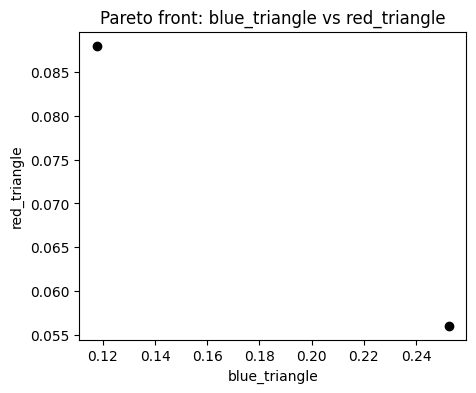

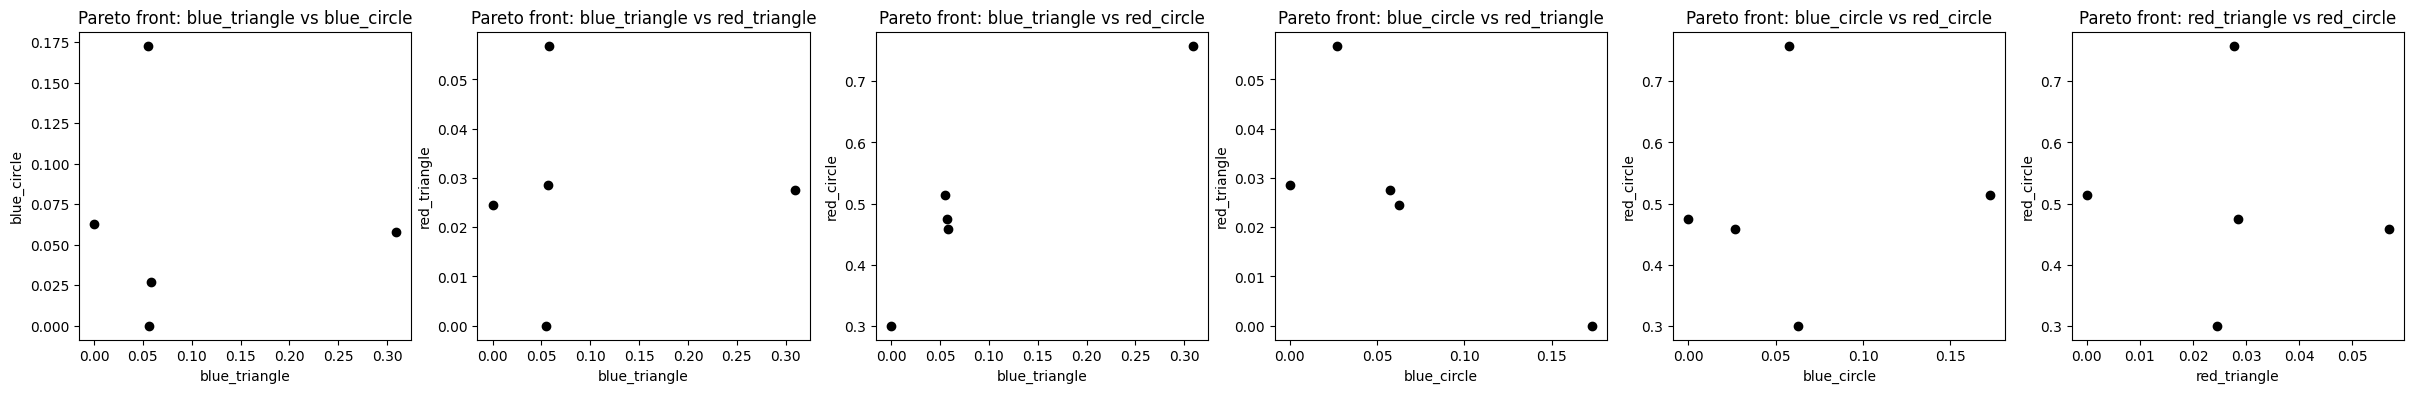

charts/SPS,███▆▆▆▅▅▄▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁
eval/cardinality,▁▁
eval/eum,▁▁
eval/hypervolume,▁▁
eval_0/discounted_vec_0,▃█▁▁▁▁▃▆▁▃▁▁▁▆▁
eval_0/discounted_vec_1,▇██▁▁▁▁▁▁█▁▁▇▁▁
eval_0/discounted_vec_2,▁▁▆█▁
eval_0/discounted_vec_3,▅▄▁▅█
eval_0/scalarized_discounted_return,▅▅▆▁▁▁▁▁▁▆▄▄▄█▆
eval_0/scalarized_return,▆▆▆▁▁▁▁▁▁▆▅▅▅█▇
+63,...


In [ ]:
# train only on triangle interpretation of the red and blue values
triangle_weight = np.array([1.0, 0.0], dtype=np.float32)  # triangle interpretation
env = CombineWrapper(
    gym.wrappers.TimeLimit(gym.make("my-four-room-v0"), max_episode_steps=MAX_EPISODE_LENGTH),
    triangle_weight,
)
train_eval_env = CombineWrapper(
    gym.wrappers.TimeLimit(gym.make("my-four-room-v0"), max_episode_steps=MAX_EPISODE_LENGTH),
    triangle_weight,
)

agent = MORLD(
    env=env,
    scalarization_method="ws",
    evaluation_mode="ser",
    policy_name="MOSACDiscrete",
    experiment_name=EXPERIMENT_NAME + "_triangle",
)

agent.train(
    total_timesteps=TOTAL_TIMESTEPS,
    eval_env=train_eval_env,
    ref_point=np.array([0, 0]),
)

visualize_front_general(agent.archive.evaluations, columns=["blue_triangle", "red_triangle"])

eval_full_four_room(agent)

agent.close_wandb()

Weights: [[0.         1.        ]
 [0.19914546 0.80085454]
 [0.39976866 0.60023134]
 [0.60048975 0.39951025]
 [0.80096818 0.19903182]
 [1.         0.        ]]
Neighborhoods: [[1], [0], [1], [4], [5], [4]]


c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:134: UserWarning: WARN: The obs returned by the `reset()` method was expecting numpy array dtype to be <class 'numpy.float32'>, actual type: int32
  logger.warn(
c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")
c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:245: UserWarning: WARN: The reward returned by `step()` must be a float, int, np.integer or np.floating, actual type: <class 'numpy.ndarray'>
  logger.warn(


Starting training...
Current pareto archive:
[array([0.08828743, 0.84200376]), array([0.37155634, 0.77998481]), array([0.37561051, 0.6840975 ])]
[]


c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:134: UserWarning: WARN: The obs returned by the `step()` method was expecting numpy array dtype to be <class 'numpy.float32'>, actual type: int32
  logger.warn(
c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `step()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")


Switching... global_steps: 40000
Updating other policies...
Current pareto archive:
[array([0.08828743, 0.84200376]), array([0.37155634, 0.77998481]), array([0.37561051, 0.6840975 ]), array([0.1112005 , 0.78507193])]
[]
Global step: 40000
Save freq: 10000
Saving checkpoint at step 40000
Saving population...
Saving archive...
Switching... global_steps: 80000
Updating other policies...
Current pareto archive:
[array([0.37155634, 0.77998481]), array([0.37561051, 0.6840975 ]), array([0.1112005 , 0.78507193]), array([0.1096613 , 0.89489999]), array([0.02472155, 1.56803138]), array([0.44781641, 0.63560448])]
[]
Global step: 80000
Save freq: 10000
Saving checkpoint at step 80000
Saving population...
Saving archive...
Switching... global_steps: 120000
Updating other policies...
Current pareto archive:
[array([0.02472155, 1.56803138]), array([0.        , 1.66260167]), array([0.15194921, 1.49994336]), array([0.5319845 , 0.84105167])]
[]
Global step: 120000
Save freq: 10000
Saving checkpoint at s

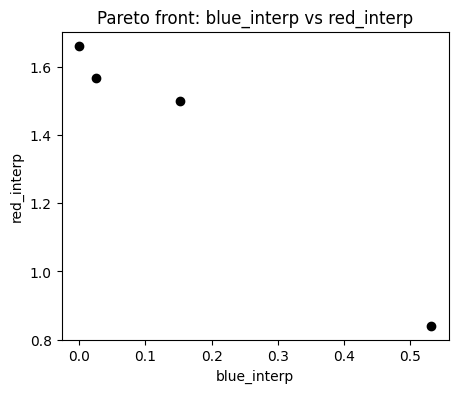

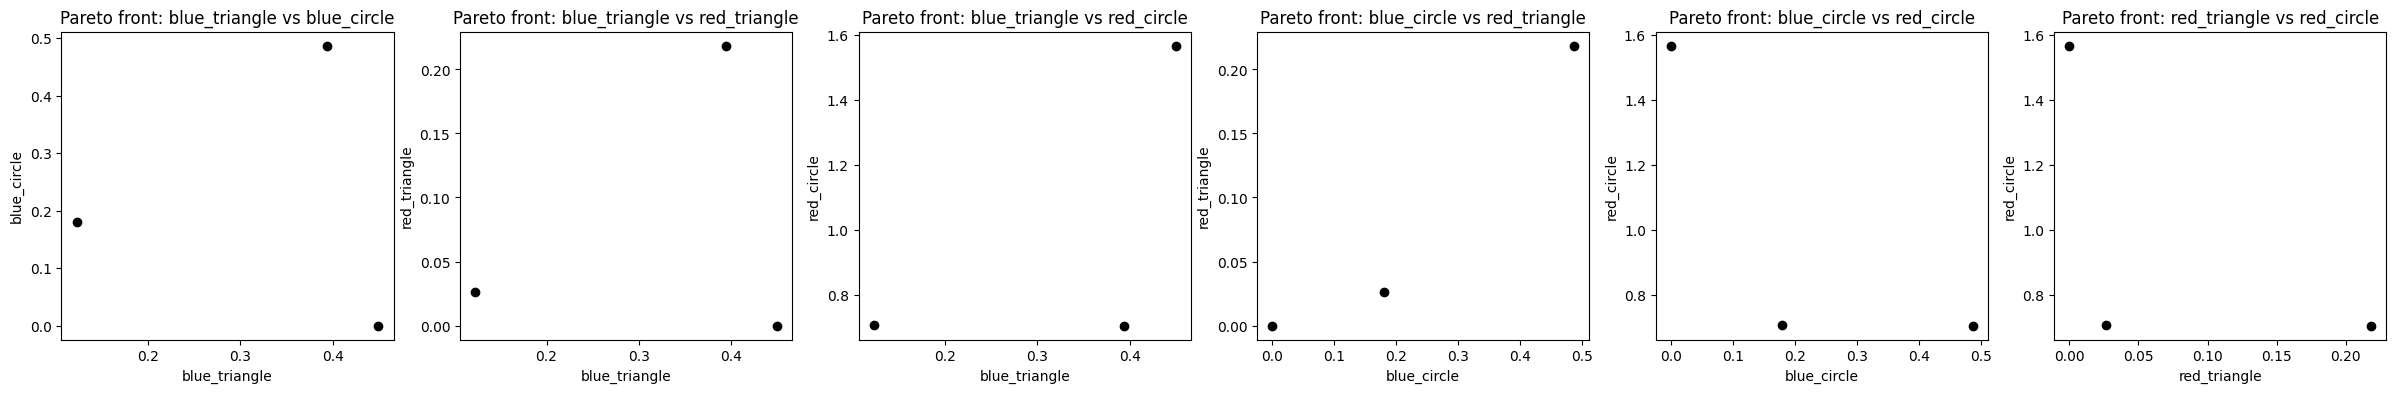

charts/SPS,█▇▆▆▄▃▃▃▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
eval/cardinality,▁▃█▃
eval/eum,▁▁▇█
eval/hypervolume,▁▁▃█
eval_0/discounted_vec_0,█▁▁▁▁▃▁▁▅▃▅▁▁▅▁▁▁▁▁▁▁▁▁▁▁
eval_0/discounted_vec_1,▆█▅▅█▅▇█▄▆▆█▆▇▆▁▁▁▁▁▁▁▁▁▁
eval_0/discounted_vec_2,▁▁▁▁▁
eval_0/discounted_vec_3,▁▁▁▁▁
eval_0/scalarized_discounted_return,▆█▅▅█▅▇█▄▆▆█▆▇▆▁▁▁▁▁▁▁▁▁▁
eval_0/scalarized_return,▆█▅▅█▅██▄▆▆█▆▇▇▁▁▁▁▁▁▁▁▁▁
+79,...


In [ ]:
# train only on circle 
weight_vec = np.array([0.0, 1.0], dtype=np.float32)  # circle interpretation
env = CombineWrapper(
    gym.wrappers.TimeLimit(gym.make("my-four-room-v0"), max_episode_steps=MAX_EPISODE_LENGTH),
    weight_vec,
)
eval_env = CombineWrapper(
    gym.wrappers.TimeLimit(gym.make("my-four-room-v0"), max_episode_steps=MAX_EPISODE_LENGTH),
    weight_vec,
)

agent = MORLD(
    env=env,
    scalarization_method="ws",
    evaluation_mode="ser",
    policy_name="MOSACDiscrete",
    experiment_name=EXPERIMENT_NAME + "_circle",
)

agent.train(
    total_timesteps=TOTAL_TIMESTEPS,
    eval_env=eval_env,
    ref_point=np.array([0, 0]),
)
visualize_front_general(agent.archive.evaluations, columns=["blue_circle", "red_circle"])

eval_full_four_room(agent)

agent.close_wandb()


c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Weight sweep:   0%|          | 0/10 [00:00<?, ?it/s]

Weights: [[0.         1.        ]
 [0.19914546 0.80085454]
 [0.39976866 0.60023134]
 [0.60048975 0.39951025]
 [0.80096818 0.19903182]
 [1.         0.        ]]
Neighborhoods: [[1], [0], [1], [4], [5], [4]]


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: kristofs (kristofs-ai) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:134: UserWarning: WARN: The obs returned by the `reset()` method was expecting numpy array dtype to be <class 'numpy.float32'>, actual type: int32
  logger.warn(
c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")
c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:245: UserWarning: WARN: The reward returned by `step()` must be a float, int, np.integer or np.floating, actual type: <class 'numpy.ndarray'>
  logger.warn(


Starting training...
Current pareto archive:
[array([0.58654314, 0.62890434]), array([0.39464371, 0.98098089]), array([0.62575105, 0.11761893])]
[]


c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:134: UserWarning: WARN: The obs returned by the `step()` method was expecting numpy array dtype to be <class 'numpy.float32'>, actual type: int32
  logger.warn(
c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `step()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")
c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:245: UserWarning: WARN: The reward returned by `step()` must be a float, int, np.integer or np.floating, actual type: <class 'numpy.ndarray'>
  logger.warn(


Switching... global_steps: 40000
Updating other policies...
Current pareto archive:
[array([0.58654314, 0.62890434]), array([0.39464371, 0.98098089]), array([0.15683672, 2.36072327]), array([0.6667243 , 0.62693218])]
[]
Global step: 40000
Save freq: 10000
Saving checkpoint at step 40000
Saving population...
Saving archive...
Switching... global_steps: 80000
Updating other policies...
Current pareto archive:
[array([0.15683672, 2.36072327]), array([0.0796    , 2.71360173]), array([0.74849345, 2.35226719]), array([0.78651732, 0.66672822])]
[]
Global step: 80000
Save freq: 10000
Saving checkpoint at step 80000
Saving population...
Saving archive...
Switching... global_steps: 120000
Updating other policies...
Current pareto archive:
[array([0.0796    , 2.71360173]), array([0.74849345, 2.35226719]), array([0.19722482, 2.44720907]), array([1.61519099, 1.05782852])]
[]
Global step: 120000
Save freq: 10000
Saving checkpoint at step 120000
Saving population...
Saving archive...
done!


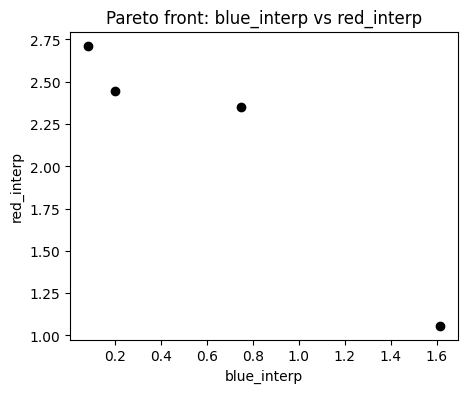

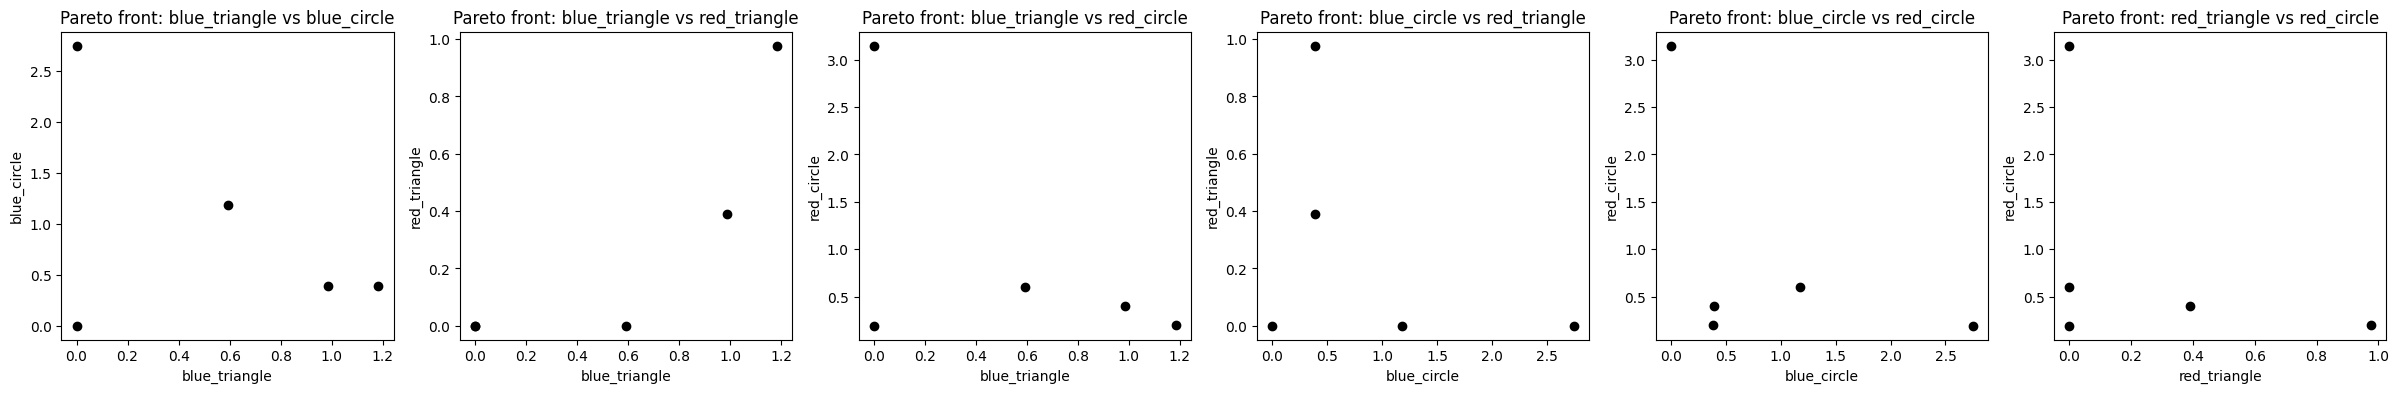

charts/SPS,█▆▅▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
eval/cardinality,▁███
eval/eum,▁▅▇█
eval/hypervolume,▁▂▅█
eval_0/discounted_vec_0,▅▅▅▅█▁▁▁▁█▃▁▁▃▁▁▁▁▁▁▁
eval_0/discounted_vec_1,▃▁▁▄▁▇█▅█▅██▇▇█▇▆▇▇▆▁
eval_0/discounted_vec_2,▁
eval_0/discounted_vec_3,▁
eval_0/scalarized_discounted_return,▃▁▁▄▁▇█▅█▅██▇▇█▇▆▇▇▆▂
eval_0/scalarized_return,▃▁▁▄▁▇█▅█▅██▇▇█▇▆▇▇▆▂
+79,...


Weight sweep:  10%|█         | 1/10 [09:20<1:24:08, 560.96s/it]

Weights: [[0.         1.        ]
 [0.19914546 0.80085454]
 [0.39976866 0.60023134]
 [0.60048975 0.39951025]
 [0.80096818 0.19903182]
 [1.         0.        ]]
Neighborhoods: [[1], [0], [1], [4], [5], [4]]


c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:134: UserWarning: WARN: The obs returned by the `reset()` method was expecting numpy array dtype to be <class 'numpy.float32'>, actual type: int32
  logger.warn(
c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")
c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:245: UserWarning: WARN: The reward returned by `step()` must be a float, int, np.integer or np.floating, actual type: <class 'numpy.ndarray'>
  logger.warn(


Starting training...
Current pareto archive:
[array([0.79803088, 0.57690796]), array([0.60762118, 0.58599747]), array([0.37086261, 0.81930593])]
[]


c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:134: UserWarning: WARN: The obs returned by the `step()` method was expecting numpy array dtype to be <class 'numpy.float32'>, actual type: int32
  logger.warn(
c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `step()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")


Switching... global_steps: 40000
Updating other policies...
Current pareto archive:
[array([0.79803088, 0.57690796]), array([0.17955105, 2.05944941]), array([0.78129874, 0.88219096])]
[]
Global step: 40000
Save freq: 10000
Saving checkpoint at step 40000
Saving population...
Saving archive...
Switching... global_steps: 80000
Updating other policies...
Current pareto archive:
[array([0.79803088, 0.57690796]), array([0.78129874, 0.88219096]), array([0.25842842, 2.39398244]), array([0.31646568, 2.29251411]), array([0.79644133, 0.66502567])]
[]
Global step: 80000
Save freq: 10000
Saving checkpoint at step 80000
Saving population...
Saving archive...
Switching... global_steps: 120000
Updating other policies...
Current pareto archive:
[array([0.78129874, 0.88219096]), array([0.25842842, 2.39398244]), array([0.31646568, 2.29251411]), array([0.17618222, 2.45462657]), array([2.23660699, 0.66857497])]
[]
Global step: 120000
Save freq: 10000
Saving checkpoint at step 120000
Saving population...
S

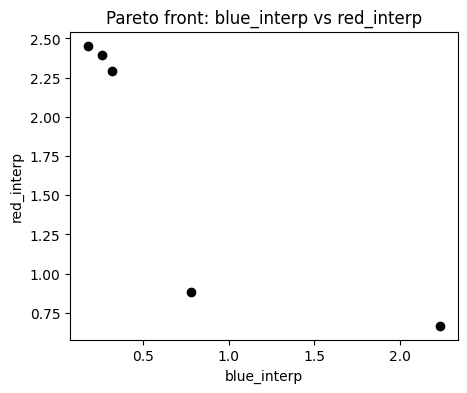

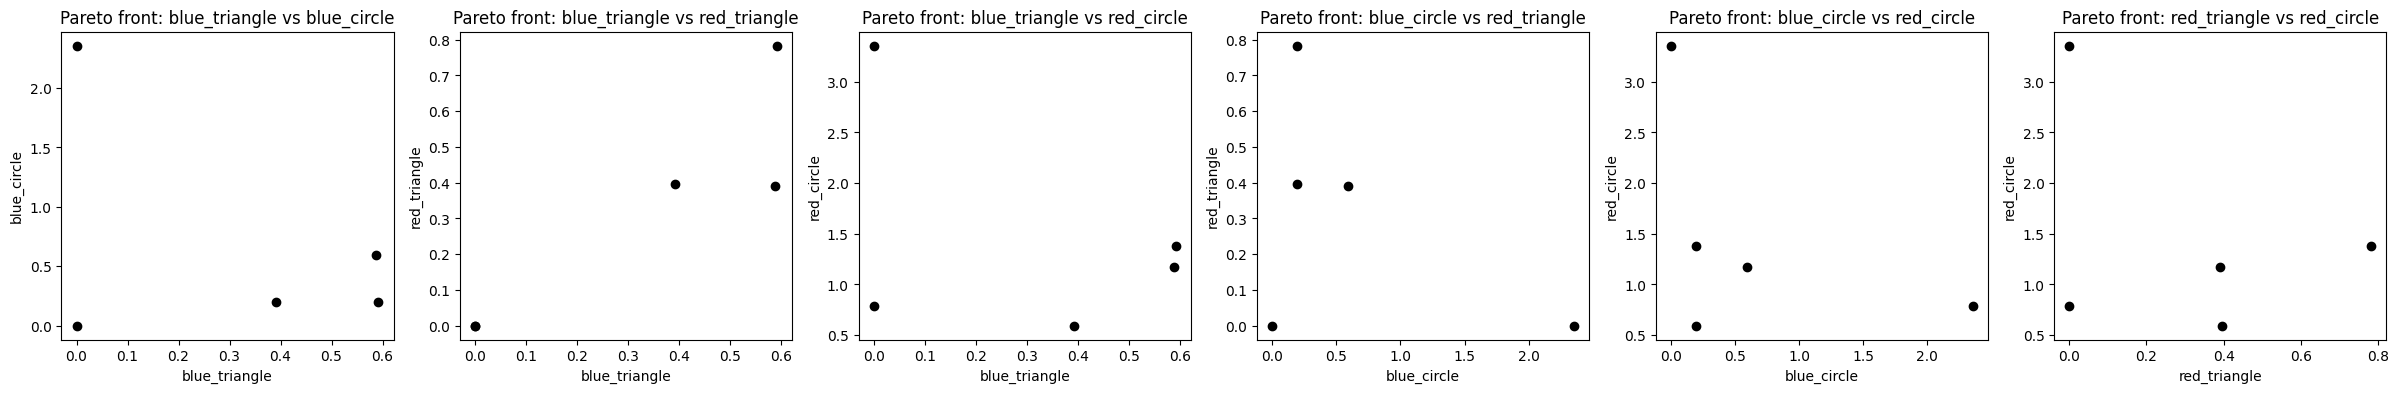

charts/SPS,█▃▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
eval/cardinality,▁▁██
eval/eum,▁▄▅█
eval/hypervolume,▁▃▄█
eval_0/discounted_vec_0,▅▂▄▂█▁▂▃▁▃▁▁▃▃▃▁▁▁▁▁▁
eval_0/discounted_vec_1,▂▂▄▃▂▅▅▇▆▆█▆▅█▇▃▂▄▄▅▁
eval_0/discounted_vec_2,▁
eval_0/discounted_vec_3,▁
eval_0/scalarized_discounted_return,▁▁▄▂▁▅▅▇▆▅█▆▅█▇▃▂▄▄▅▁
eval_0/scalarized_return,▁▁▄▂▁▅▅▇▆▅█▆▅█▇▃▂▄▄▅▁
+79,...


Weight sweep:  20%|██        | 2/10 [21:23<1:27:26, 655.83s/it]

Weights: [[0.         1.        ]
 [0.19914546 0.80085454]
 [0.39976866 0.60023134]
 [0.60048975 0.39951025]
 [0.80096818 0.19903182]
 [1.         0.        ]]
Neighborhoods: [[1], [0], [1], [4], [5], [4]]


c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:134: UserWarning: WARN: The obs returned by the `reset()` method was expecting numpy array dtype to be <class 'numpy.float32'>, actual type: int32
  logger.warn(
c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")
c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:245: UserWarning: WARN: The reward returned by `step()` must be a float, int, np.integer or np.floating, actual type: <class 'numpy.ndarray'>
  logger.warn(


Starting training...
Current pareto archive:
[array([0.68489643, 0.86458396]), array([0.74714325, 0.60968153]), array([0.95813418, 0.40188956])]
[]


c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:134: UserWarning: WARN: The obs returned by the `step()` method was expecting numpy array dtype to be <class 'numpy.float32'>, actual type: int32
  logger.warn(
c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `step()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")


Switching... global_steps: 40000
Updating other policies...
Current pareto archive:
[array([0.68489643, 0.86458396]), array([0.74714325, 0.60968153]), array([0.95813418, 0.40188956]), array([0.06099397, 1.92063726])]
[]
Global step: 40000
Save freq: 10000
Saving checkpoint at step 40000
Saving population...
Saving archive...
Switching... global_steps: 80000
Updating other policies...
Current pareto archive:
[array([0.95813418, 0.40188956]), array([0.06099397, 1.92063726]), array([0.03095556, 2.1866993 ]), array([0.79240605, 1.55931134])]
[]
Global step: 80000
Save freq: 10000
Saving checkpoint at step 80000
Saving population...
Saving archive...
Switching... global_steps: 120000
Updating other policies...
Current pareto archive:
[array([0.95813418, 0.40188956]), array([0.03095556, 2.1866993 ]), array([0.79240605, 1.55931134]), array([0.34490548, 2.09344319]), array([1.96900562, 0.34762589])]
[]
Global step: 120000
Save freq: 10000
Saving checkpoint at step 120000
Saving population...
S

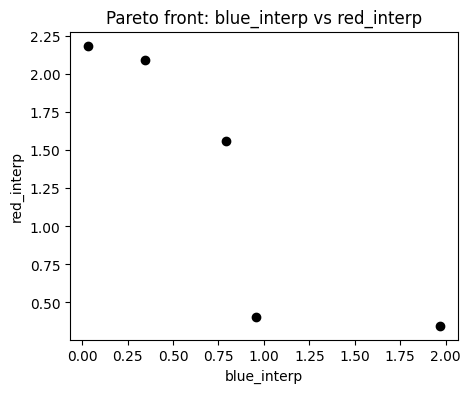

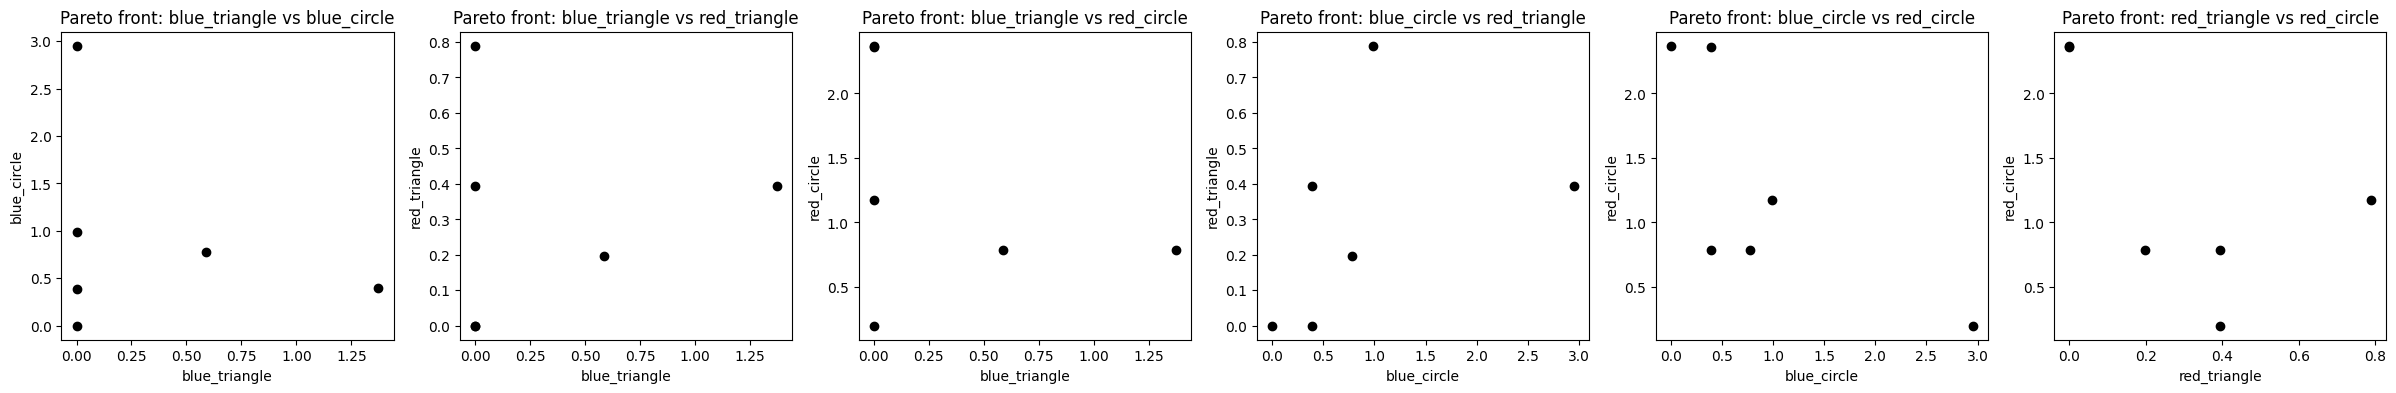

charts/SPS,█▆▃▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
eval/cardinality,▁▅▅█
eval/eum,▁▄▅█
eval/hypervolume,▁▁▅█
eval_0/discounted_vec_0,▅█▅▁▂▂▁▂▁▁▁▁▂▁▁▁▁▁▁▁▁
eval_0/discounted_vec_1,▁▂▁▅▁▆▅▇█▇██▇▇▇▆▇▇▇▆▁
eval_0/discounted_vec_2,▁
eval_0/discounted_vec_3,▁
eval_0/scalarized_discounted_return,▁▂▁▅▁▆▅▇█▇██▇▇▇▆▇▇▇▆▃
eval_0/scalarized_return,▁▂▁▅▁▆▅▇█▇██▇▇▇▆▇▇▇▆▃
+79,...


Weight sweep:  30%|███       | 3/10 [32:27<1:16:56, 659.52s/it]

Weights: [[0.         1.        ]
 [0.19914546 0.80085454]
 [0.39976866 0.60023134]
 [0.60048975 0.39951025]
 [0.80096818 0.19903182]
 [1.         0.        ]]
Neighborhoods: [[1], [0], [1], [4], [5], [4]]


c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:134: UserWarning: WARN: The obs returned by the `reset()` method was expecting numpy array dtype to be <class 'numpy.float32'>, actual type: int32
  logger.warn(
c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")
c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:245: UserWarning: WARN: The reward returned by `step()` must be a float, int, np.integer or np.floating, actual type: <class 'numpy.ndarray'>
  logger.warn(


Starting training...
Current pareto archive:
[array([0.71913522, 0.72163705]), array([0.90440714, 0.287853  ])]
[]


c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:134: UserWarning: WARN: The obs returned by the `step()` method was expecting numpy array dtype to be <class 'numpy.float32'>, actual type: int32
  logger.warn(
c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `step()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")


Switching... global_steps: 40000
Updating other policies...
Current pareto archive:
[array([0.71913522, 0.72163705]), array([0.90440714, 0.287853  ]), array([0.19571304, 1.77931982]), array([0.75789593, 0.32712926])]
[]
Global step: 40000
Save freq: 10000
Saving checkpoint at step 40000
Saving population...
Saving archive...
Switching... global_steps: 80000
Updating other policies...
Current pareto archive:
[array([0.90440714, 0.287853  ]), array([0.19571304, 1.77931982]), array([0.75789593, 0.32712926]), array([0.09102485, 1.83846945]), array([0.27537443, 1.5441526 ]), array([0.74790406, 0.83808009])]
[]
Global step: 80000
Save freq: 10000
Saving checkpoint at step 80000
Saving population...
Saving archive...
Switching... global_steps: 120000
Updating other policies...
Current pareto archive:
[array([0.19571304, 1.77931982]), array([0.09102485, 1.83846945]), array([0.27537443, 1.5441526 ]), array([1.0475766, 1.2446087])]
[]
Global step: 120000
Save freq: 10000
Saving checkpoint at ste

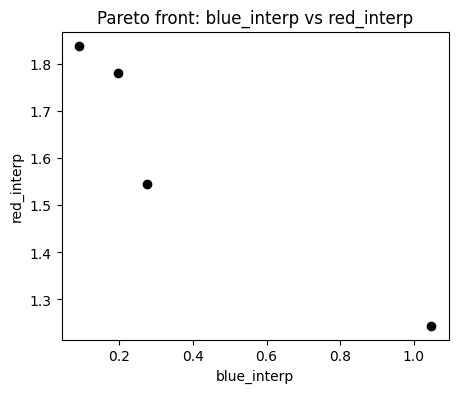

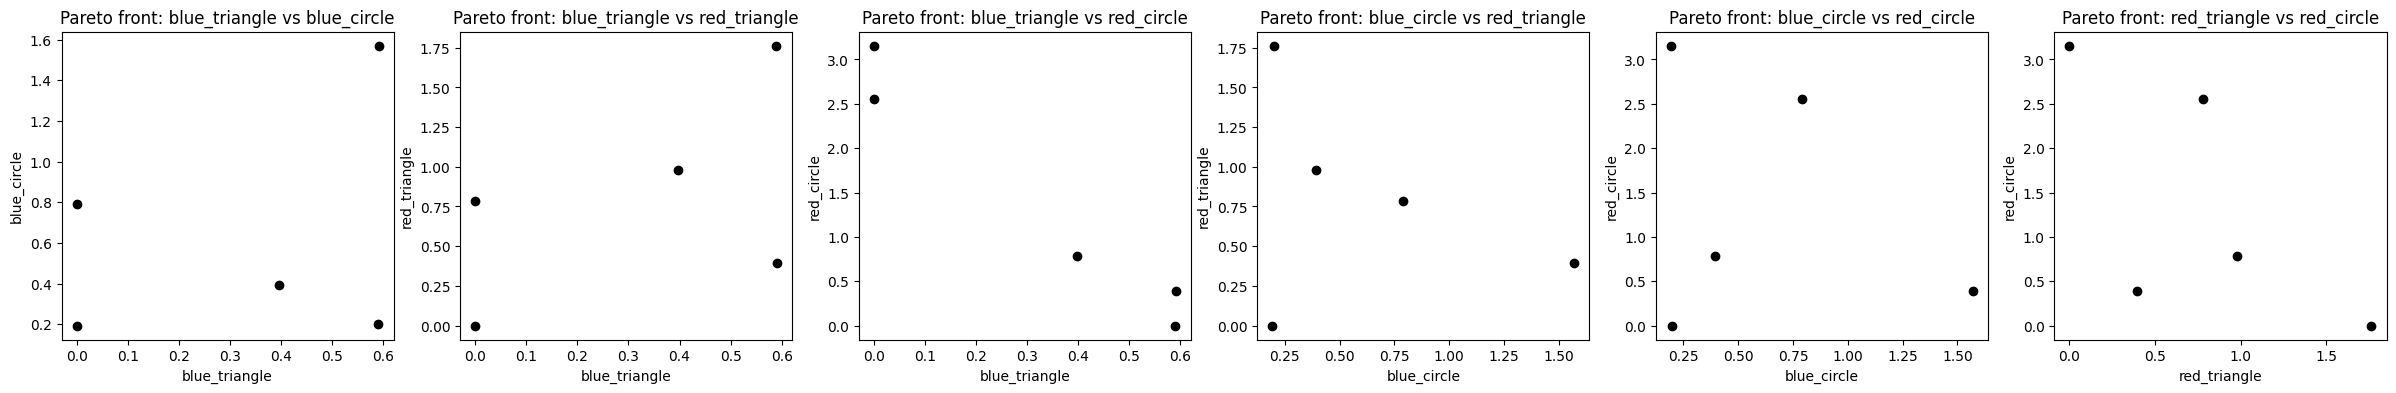

charts/SPS,██▄▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
eval/cardinality,▁▅█▅
eval/eum,▁▆▆█
eval/hypervolume,▁▃▄█
eval_0/discounted_vec_0,▃▆▄▅█▃▁▁▂▄▂▃▁▁▁▁▁▁▁▁▁
eval_0/discounted_vec_1,▃▃▄▄▃▇▇█▇▅▆▆█▇▇▅▆▆▆▆▁
eval_0/discounted_vec_2,▁
eval_0/discounted_vec_3,▁
eval_0/scalarized_discounted_return,▂▂▃▃▁▆▆▇▆▅▆▅█▇▆▄▅▅▅▅▁
eval_0/scalarized_return,▂▂▃▃▁▆▆▇▆▅▆▅█▇▆▄▅▅▅▅▁
+79,...


Weight sweep:  40%|████      | 4/10 [42:41<1:04:10, 641.69s/it]

Weights: [[0.         1.        ]
 [0.19914546 0.80085454]
 [0.39976866 0.60023134]
 [0.60048975 0.39951025]
 [0.80096818 0.19903182]
 [1.         0.        ]]
Neighborhoods: [[1], [0], [1], [4], [5], [4]]


c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:134: UserWarning: WARN: The obs returned by the `reset()` method was expecting numpy array dtype to be <class 'numpy.float32'>, actual type: int32
  logger.warn(
c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")
c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:245: UserWarning: WARN: The reward returned by `step()` must be a float, int, np.integer or np.floating, actual type: <class 'numpy.ndarray'>
  logger.warn(


Starting training...
Current pareto archive:
[array([0.50107479, 0.50299703]), array([0.30064081, 0.80092832]), array([1.08772268, 0.42791373]), array([0.76694815, 0.49238621])]
[]


c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:134: UserWarning: WARN: The obs returned by the `step()` method was expecting numpy array dtype to be <class 'numpy.float32'>, actual type: int32
  logger.warn(
c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `step()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")


Switching... global_steps: 40000
Updating other policies...
Current pareto archive:
[array([0.30064081, 0.80092832]), array([1.08772268, 0.42791373]), array([0.76694815, 0.49238621]), array([0.14426785, 1.57108285]), array([0.63301277, 0.57375741]), array([0.53605556, 0.73392159])]
[]
Global step: 40000
Save freq: 10000
Saving checkpoint at step 40000
Saving population...
Saving archive...
Switching... global_steps: 80000
Updating other policies...
Current pareto archive:
[array([1.08772268, 0.42791373]), array([0.14426785, 1.57108285]), array([0.1751354 , 1.38885338]), array([0.82919811, 0.77895137]), array([0.4284461 , 0.81102312])]
[]
Global step: 80000
Save freq: 10000
Saving checkpoint at step 80000
Saving population...
Saving archive...
Switching... global_steps: 120000
Updating other policies...
Current pareto archive:
[array([1.08772268, 0.42791373]), array([0.14426785, 1.57108285]), array([0.82919811, 0.77895137]), array([0.4284461 , 0.81102312]), array([0.34544392, 1.39707888

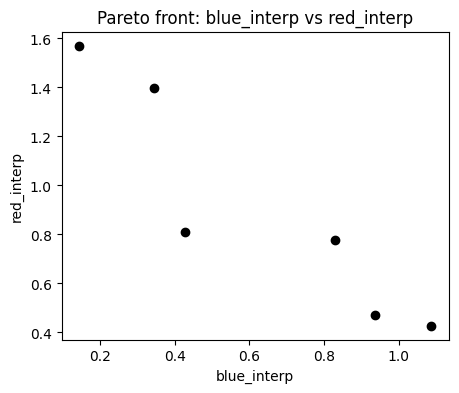

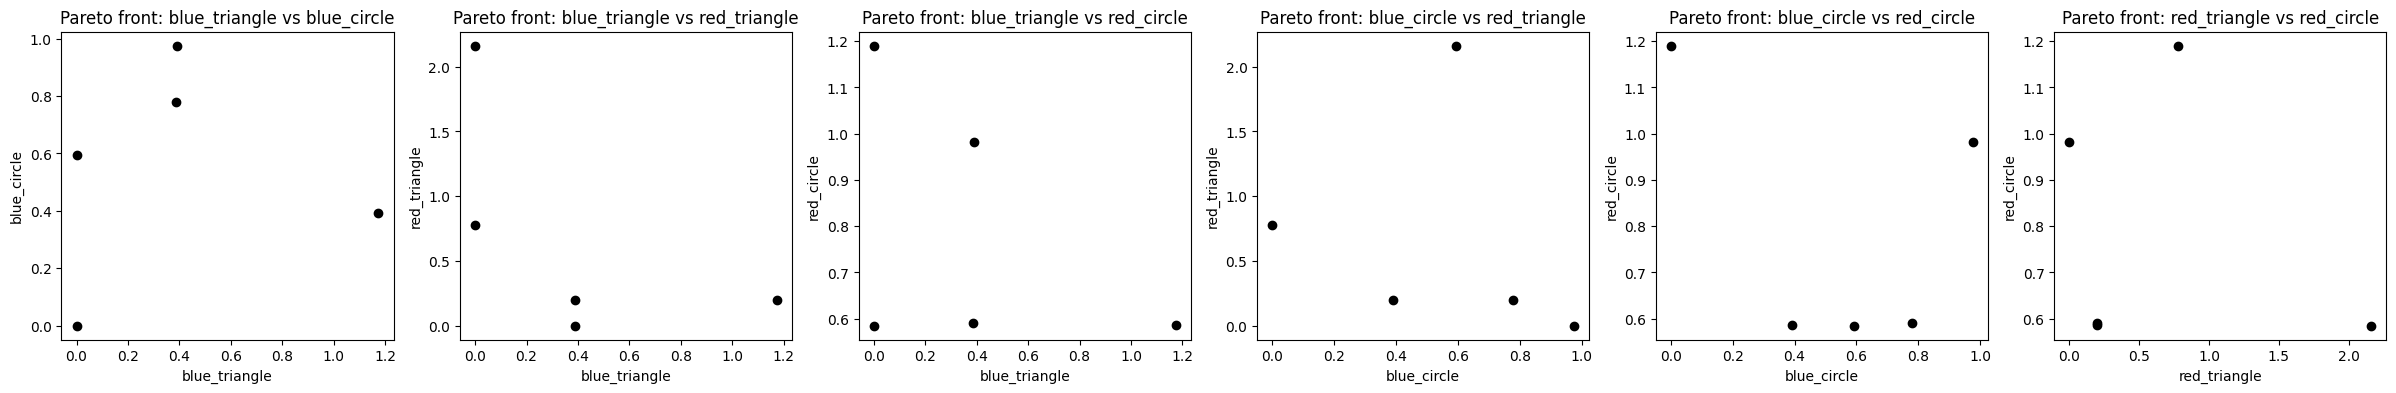

charts/SPS,█▇▆▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
eval/cardinality,▁█▅█
eval/eum,▁███
eval/hypervolume,▁▄▆█
eval_0/discounted_vec_0,▄▇▅█▇▁▁▄▃▁▄▁▁▁▁▁▁▁▁▁▁
eval_0/discounted_vec_1,▃▂▃▃▃▇▇▅▆█▅▆▇▆▆▃▃▃▂▃▁
eval_0/discounted_vec_2,▁
eval_0/discounted_vec_3,▁
eval_0/scalarized_discounted_return,▂▁▂▂▃▇▇▄▆█▅▆▇▆▆▂▃▂▁▂▁
eval_0/scalarized_return,▂▁▂▂▃▇▇▄▆█▅▆▇▆▆▂▃▂▁▂▁
+79,...


Weight sweep:  50%|█████     | 5/10 [53:09<53:03, 636.66s/it]  

Weights: [[0.         1.        ]
 [0.19914546 0.80085454]
 [0.39976866 0.60023134]
 [0.60048975 0.39951025]
 [0.80096818 0.19903182]
 [1.         0.        ]]
Neighborhoods: [[1], [0], [1], [4], [5], [4]]


c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:134: UserWarning: WARN: The obs returned by the `reset()` method was expecting numpy array dtype to be <class 'numpy.float32'>, actual type: int32
  logger.warn(
c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")
c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:245: UserWarning: WARN: The reward returned by `step()` must be a float, int, np.integer or np.floating, actual type: <class 'numpy.ndarray'>
  logger.warn(


Starting training...
Current pareto archive:
[array([0.4018853 , 0.88205105]), array([0.45378976, 0.69790148]), array([0.69377254, 0.55572733])]
[]


c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:134: UserWarning: WARN: The obs returned by the `step()` method was expecting numpy array dtype to be <class 'numpy.float32'>, actual type: int32
  logger.warn(
c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `step()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")


Switching... global_steps: 40000
Updating other policies...
Current pareto archive:
[array([0.4018853 , 0.88205105]), array([0.45378976, 0.69790148]), array([0.08347275, 1.53451583]), array([0.63139875, 0.61627036]), array([0.94998391, 0.3151497 ]), array([0.8055679 , 0.61532587])]
[]
Global step: 40000
Save freq: 10000
Saving checkpoint at step 40000
Saving population...
Saving archive...
Switching... global_steps: 80000
Updating other policies...
Current pareto archive:
[array([0.4018853 , 0.88205105]), array([0.08347275, 1.53451583]), array([0.94998391, 0.3151497 ]), array([0.8055679 , 0.61532587]), array([0.1045564 , 1.52408951]), array([0.6330188, 0.8797426])]
[]
Global step: 80000
Save freq: 10000
Saving checkpoint at step 80000
Saving population...
Saving archive...
Switching... global_steps: 120000
Updating other policies...
Current pareto archive:
[array([0.08347275, 1.53451583]), array([0.94998391, 0.3151497 ]), array([0.8055679 , 0.61532587]), array([0.1045564 , 1.52408951])

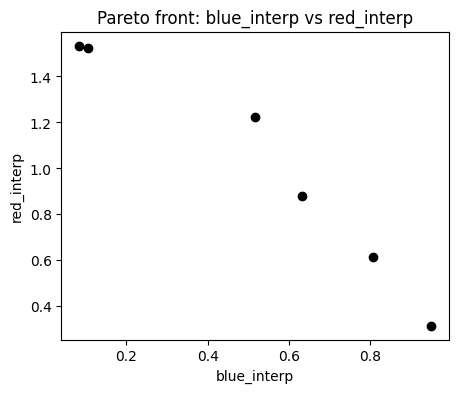

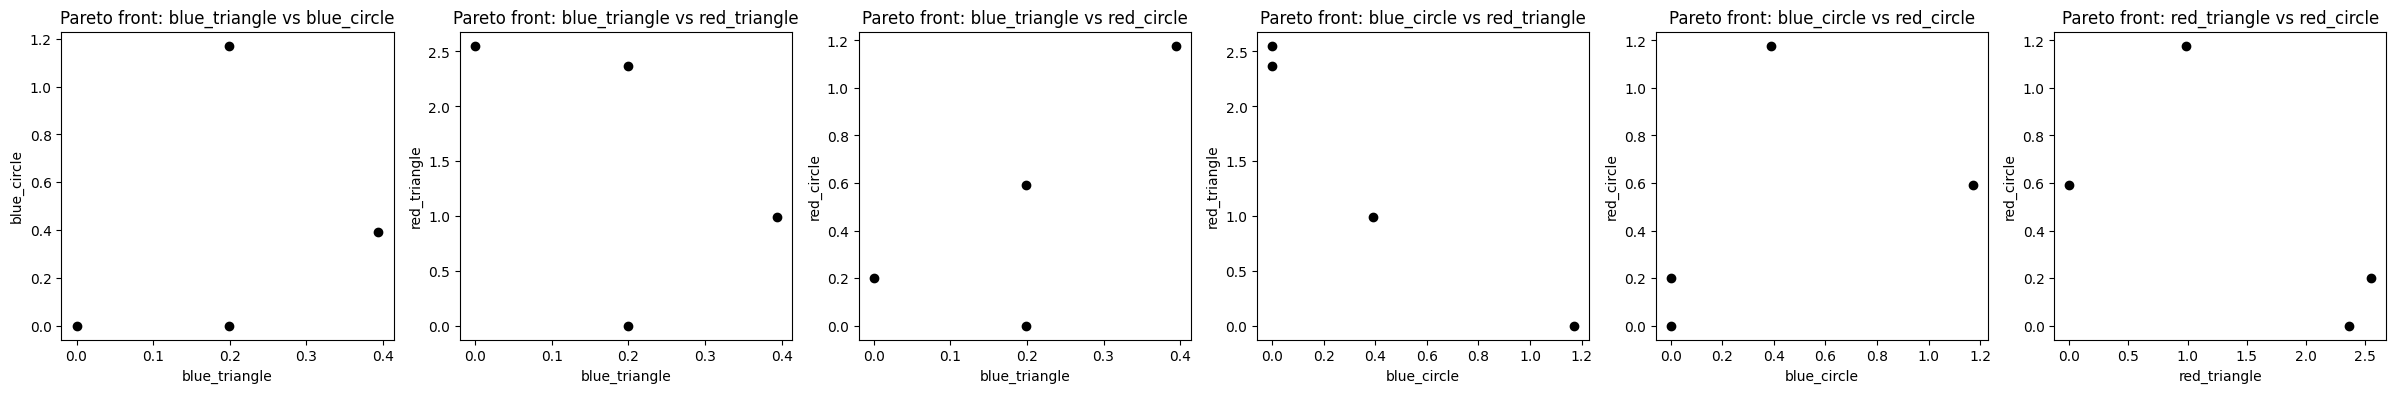

charts/SPS,█▇▆▄▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
eval/cardinality,▁███
eval/eum,▁███
eval/hypervolume,▁▄▅█
eval_0/discounted_vec_0,▅█▂▅▅▃▁▂▂▁▁▁▁▁▁▁▁▁▁▁▁
eval_0/discounted_vec_1,▅▄▆▂▅█▆▇▆█▇▅▇▇▇▁▁▁▁▁▁
eval_0/discounted_vec_2,▁
eval_0/discounted_vec_3,▁
eval_0/scalarized_discounted_return,▅▄▆▂▅█▆▇▆█▇▅▇▇▇▁▁▁▁▁▁
eval_0/scalarized_return,▅▄▆▂▅█▆▇▆█▇▅▇▇▇▁▁▁▁▁▁
+79,...


Weight sweep:  60%|██████    | 6/10 [1:03:31<42:07, 631.78s/it]

Weights: [[0.         1.        ]
 [0.19914546 0.80085454]
 [0.39976866 0.60023134]
 [0.60048975 0.39951025]
 [0.80096818 0.19903182]
 [1.         0.        ]]
Neighborhoods: [[1], [0], [1], [4], [5], [4]]


c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:134: UserWarning: WARN: The obs returned by the `reset()` method was expecting numpy array dtype to be <class 'numpy.float32'>, actual type: int32
  logger.warn(
c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")
c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:245: UserWarning: WARN: The reward returned by `step()` must be a float, int, np.integer or np.floating, actual type: <class 'numpy.ndarray'>
  logger.warn(


Starting training...
Current pareto archive:
[array([0.57354439, 0.60144866]), array([0.68091959, 0.53597007]), array([0.28687053, 0.6935926 ]), array([0.39234254, 0.60387364]), array([0.8795797 , 0.48356505])]
[]


c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:134: UserWarning: WARN: The obs returned by the `step()` method was expecting numpy array dtype to be <class 'numpy.float32'>, actual type: int32
  logger.warn(
c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `step()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")


Switching... global_steps: 40000
Updating other policies...
Current pareto archive:
[array([0.8795797 , 0.48356505]), array([0.34006823, 1.5719849 ]), array([0.75788675, 0.70803708])]
[]
Global step: 40000
Save freq: 10000
Saving checkpoint at step 40000
Saving population...
Saving archive...
Switching... global_steps: 80000
Updating other policies...
Current pareto archive:
[array([0.8795797 , 0.48356505]), array([0.34006823, 1.5719849 ]), array([0.75788675, 0.70803708]), array([0.01300332, 1.93969109]), array([1.16402592, 0.18467631])]
[]
Global step: 80000
Save freq: 10000
Saving checkpoint at step 80000
Saving population...
Saving archive...
Switching... global_steps: 120000
Updating other policies...
Current pareto archive:
[array([0.8795797 , 0.48356505]), array([0.34006823, 1.5719849 ]), array([0.75788675, 0.70803708]), array([0.01300332, 1.93969109]), array([1.16402592, 0.18467631]), array([0.78651963, 0.61608591]), array([1.02227927, 0.28844506])]
[]
Global step: 120000
Save f

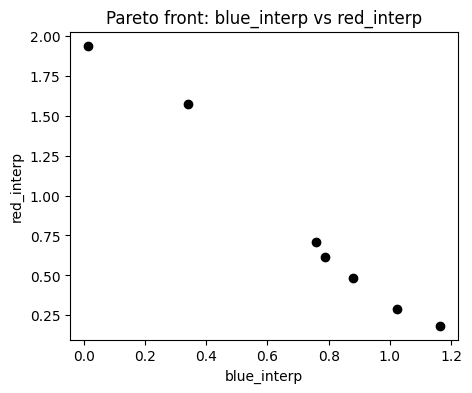

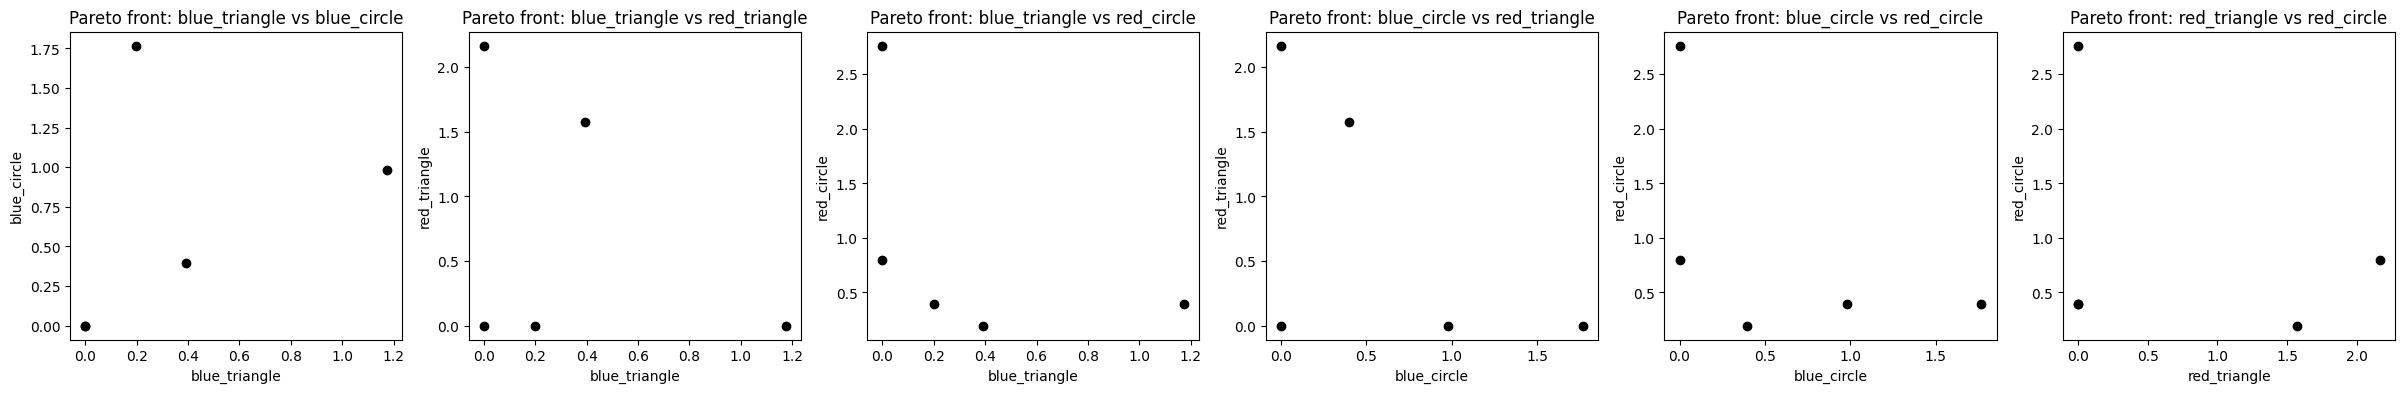

charts/SPS,█▅▄▄▄▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
eval/cardinality,▅▁▅█
eval/eum,▁▆██
eval/hypervolume,▁▇██
eval_0/discounted_vec_0,▃▄▄▅█▅▁▃▁▆▁▁▁▁▁▁▁▁▁▁▁
eval_0/discounted_vec_1,▄▂▃▄▂▆▆▆▇▆▆████▁▁▁▁▁▁
eval_0/discounted_vec_2,▁
eval_0/discounted_vec_3,▁
eval_0/scalarized_discounted_return,▄▂▃▄▂▆▆▆▇▆▆████▁▁▁▁▁▁
eval_0/scalarized_return,▄▂▃▄▂▆▆▆▇▆▆████▁▁▁▁▁▁
+79,...


Weight sweep:  70%|███████   | 7/10 [1:14:35<32:06, 642.25s/it]

Weights: [[0.         1.        ]
 [0.19914546 0.80085454]
 [0.39976866 0.60023134]
 [0.60048975 0.39951025]
 [0.80096818 0.19903182]
 [1.         0.        ]]
Neighborhoods: [[1], [0], [1], [4], [5], [4]]


c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:134: UserWarning: WARN: The obs returned by the `reset()` method was expecting numpy array dtype to be <class 'numpy.float32'>, actual type: int32
  logger.warn(
c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")
c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:245: UserWarning: WARN: The reward returned by `step()` must be a float, int, np.integer or np.floating, actual type: <class 'numpy.ndarray'>
  logger.warn(


Starting training...
Current pareto archive:
[array([0.44347784, 0.7935549 ]), array([0.5911352 , 0.72095142]), array([0.30935358, 0.95585423]), array([0.68983755, 0.39089947]), array([0.6781564 , 0.60225684])]
[]


c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:134: UserWarning: WARN: The obs returned by the `step()` method was expecting numpy array dtype to be <class 'numpy.float32'>, actual type: int32
  logger.warn(
c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `step()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")


Switching... global_steps: 40000
Updating other policies...
Current pareto archive:
[array([0.30935358, 0.95585423]), array([0.13135253, 2.07015996]), array([1.14518956, 0.39560483]), array([1.03656834, 0.93952237])]
[]
Global step: 40000
Save freq: 10000
Saving checkpoint at step 40000
Saving population...
Saving archive...
Switching... global_steps: 80000
Updating other policies...
Current pareto archive:
[array([0.13135253, 2.07015996]), array([1.14518956, 0.39560483]), array([1.03656834, 0.93952237]), array([0.36584072, 1.68625449])]
[]
Global step: 80000
Save freq: 10000
Saving checkpoint at step 80000
Saving population...
Saving archive...
Switching... global_steps: 120000
Updating other policies...
Current pareto archive:
[array([1.14518956, 0.39560483]), array([1.03656834, 0.93952237]), array([0.39796524, 2.11223833])]
[]
Global step: 120000
Save freq: 10000
Saving checkpoint at step 120000
Saving population...
Saving archive...
done!


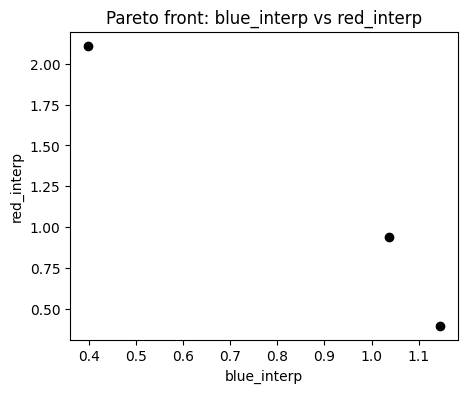

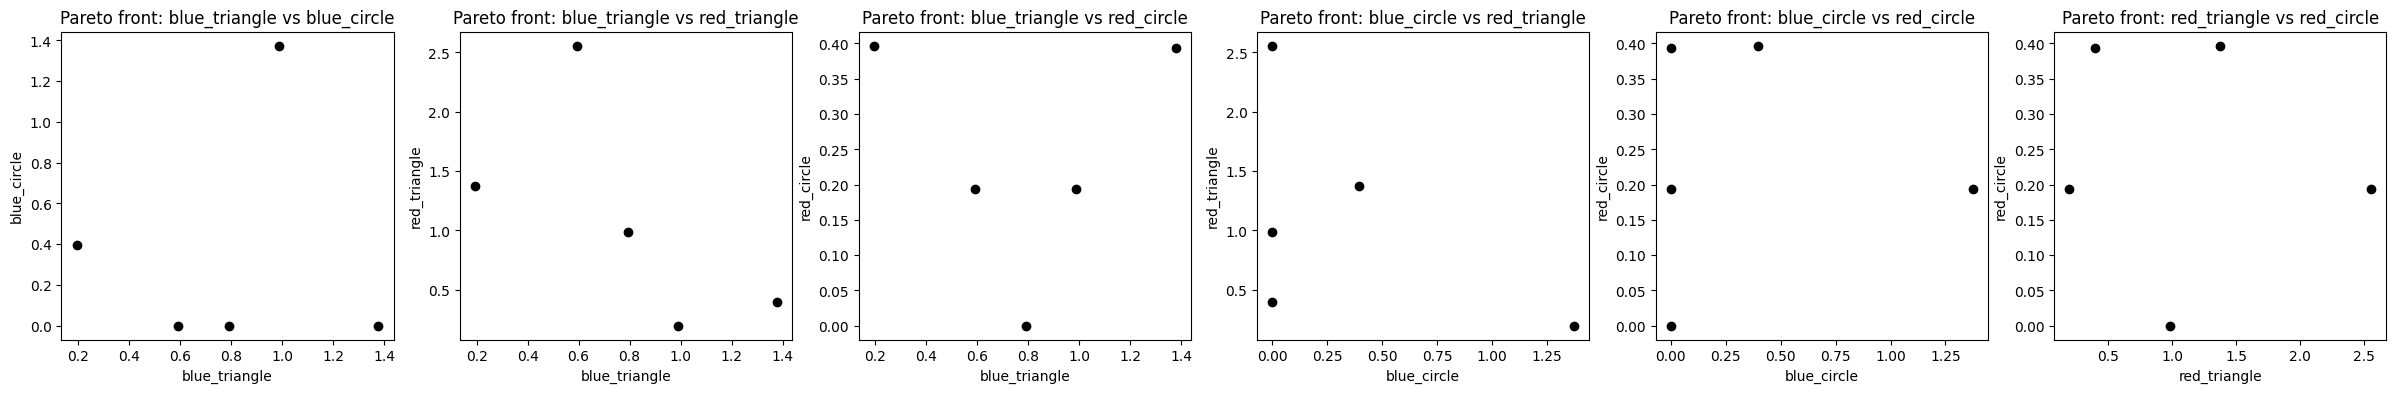

charts/SPS,█▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
eval/cardinality,█▅▅▁
eval/eum,▁▇▇█
eval/hypervolume,▁▆▇█
eval_0/discounted_vec_0,▆▃▇▆█▁▁▄▄▁▁▂▁▁▁▁▁▁▁▁▁
eval_0/discounted_vec_1,▂▂▃▂▃█▆▆▇▅▇█▆▅▆▁▁▂▁▁▁
eval_0/discounted_vec_2,▁
eval_0/discounted_vec_3,▁
eval_0/scalarized_discounted_return,▂▂▃▂▃█▆▆▇▅▇█▆▅▆▁▁▂▁▁▁
eval_0/scalarized_return,▂▂▃▂▃█▆▆▇▅▇█▆▅▆▁▁▂▁▁▁
+79,...


Weight sweep:  80%|████████  | 8/10 [1:23:35<20:19, 609.68s/it]

Weights: [[0.         1.        ]
 [0.19914546 0.80085454]
 [0.39976866 0.60023134]
 [0.60048975 0.39951025]
 [0.80096818 0.19903182]
 [1.         0.        ]]
Neighborhoods: [[1], [0], [1], [4], [5], [4]]


c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:134: UserWarning: WARN: The obs returned by the `reset()` method was expecting numpy array dtype to be <class 'numpy.float32'>, actual type: int32
  logger.warn(
c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")
c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:245: UserWarning: WARN: The reward returned by `step()` must be a float, int, np.integer or np.floating, actual type: <class 'numpy.ndarray'>
  logger.warn(


Starting training...
Current pareto archive:
[array([0.83139762, 0.5589126 ]), array([0.61520392, 0.71992821]), array([0.53413363, 0.75121201])]
[]


c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:134: UserWarning: WARN: The obs returned by the `step()` method was expecting numpy array dtype to be <class 'numpy.float32'>, actual type: int32
  logger.warn(
c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `step()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")


Switching... global_steps: 40000
Updating other policies...
Current pareto archive:
[array([0.83139762, 0.5589126 ]), array([0.61520392, 0.71992821]), array([0.53413363, 0.75121201]), array([0.21514894, 2.19407795]), array([0.31686301, 0.78649076])]
[]
Global step: 40000
Save freq: 10000
Saving checkpoint at step 40000
Saving population...
Saving archive...
Switching... global_steps: 80000
Updating other policies...
Current pareto archive:
[array([0.83139762, 0.5589126 ]), array([0.61520392, 0.71992821]), array([0.53413363, 0.75121201]), array([0.21514894, 2.19407795]), array([0.        , 2.28665543]), array([0.17815703, 2.26592808]), array([0.91635576, 0.5111633 ]), array([0.45997814, 0.78678947])]
[]
Global step: 80000
Save freq: 10000
Saving checkpoint at step 80000
Saving population...
Saving archive...
Switching... global_steps: 120000
Updating other policies...
Current pareto archive:
[array([0.21514894, 2.19407795]), array([0.        , 2.28665543]), array([0.17815703, 2.26592808

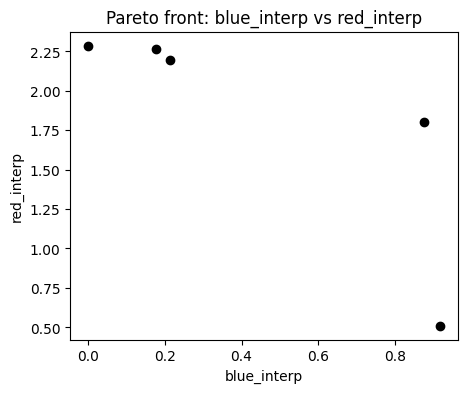

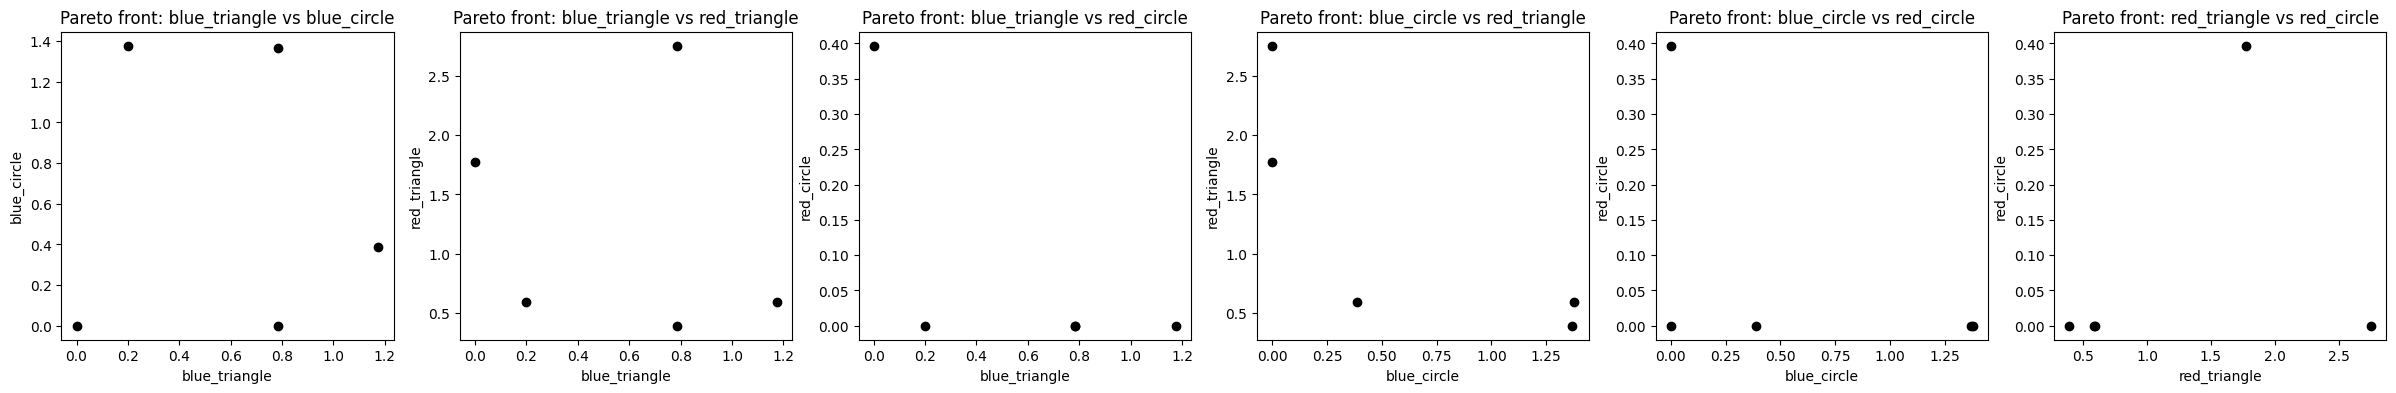

charts/SPS,█▅▄▃▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
eval/cardinality,▁▄█▄
eval/eum,▁▇▇█
eval/hypervolume,▁▃▃█
eval_0/discounted_vec_0,▃█▄▇▄▁▁▄▃▅▁▁▁▁▁▁▁▁▁▁▁
eval_0/discounted_vec_1,▂▁▂▃▂▇▇▇▆▅▅▆██▇▂▁▂▁▁▁
eval_0/discounted_vec_2,▁
eval_0/discounted_vec_3,▁
eval_0/scalarized_discounted_return,▂▁▂▃▂▇▇▇▆▅▅▆██▇▂▁▂▁▁▁
eval_0/scalarized_return,▂▁▂▃▂▇▇▇▆▅▅▆██▇▂▁▂▁▁▁
+79,...


Weight sweep:  90%|█████████ | 9/10 [1:32:25<09:45, 585.00s/it]

Weights: [[0.         1.        ]
 [0.19914546 0.80085454]
 [0.39976866 0.60023134]
 [0.60048975 0.39951025]
 [0.80096818 0.19903182]
 [1.         0.        ]]
Neighborhoods: [[1], [0], [1], [4], [5], [4]]


c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:134: UserWarning: WARN: The obs returned by the `reset()` method was expecting numpy array dtype to be <class 'numpy.float32'>, actual type: int32
  logger.warn(
c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")
c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:245: UserWarning: WARN: The reward returned by `step()` must be a float, int, np.integer or np.floating, actual type: <class 'numpy.ndarray'>
  logger.warn(


Starting training...
Current pareto archive:
[array([0.86413531, 0.66634895]), array([0.50990432, 1.05998887])]
[]


c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:134: UserWarning: WARN: The obs returned by the `step()` method was expecting numpy array dtype to be <class 'numpy.float32'>, actual type: int32
  logger.warn(
c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `step()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")


Switching... global_steps: 40000
Updating other policies...
Current pareto archive:
[array([0.86413531, 0.66634895]), array([0.50990432, 1.05998887]), array([0.15761693, 2.75006316]), array([0.55028648, 0.82278274])]
[]
Global step: 40000
Save freq: 10000
Saving checkpoint at step 40000
Saving population...
Saving archive...
Switching... global_steps: 80000
Updating other policies...
Current pareto archive:
[array([0.50990432, 1.05998887]), array([0.15761693, 2.75006316]), array([0.55028648, 0.82278274]), array([0.90199661, 0.66869253]), array([0.5100964 , 1.02079763])]
[]
Global step: 80000
Save freq: 10000
Saving checkpoint at step 80000
Saving population...
Saving archive...
Switching... global_steps: 120000
Updating other policies...
Current pareto archive:
[array([0.50990432, 1.05998887]), array([0.15761693, 2.75006316]), array([0.55028648, 0.82278274]), array([0.90199661, 0.66869253]), array([0.5100964 , 1.02079763]), array([0.43011816, 2.47441852])]
[]
Global step: 120000
Save f

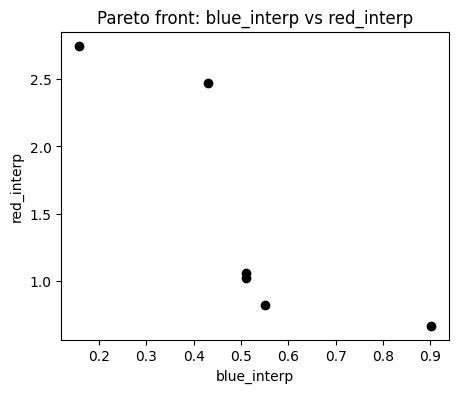

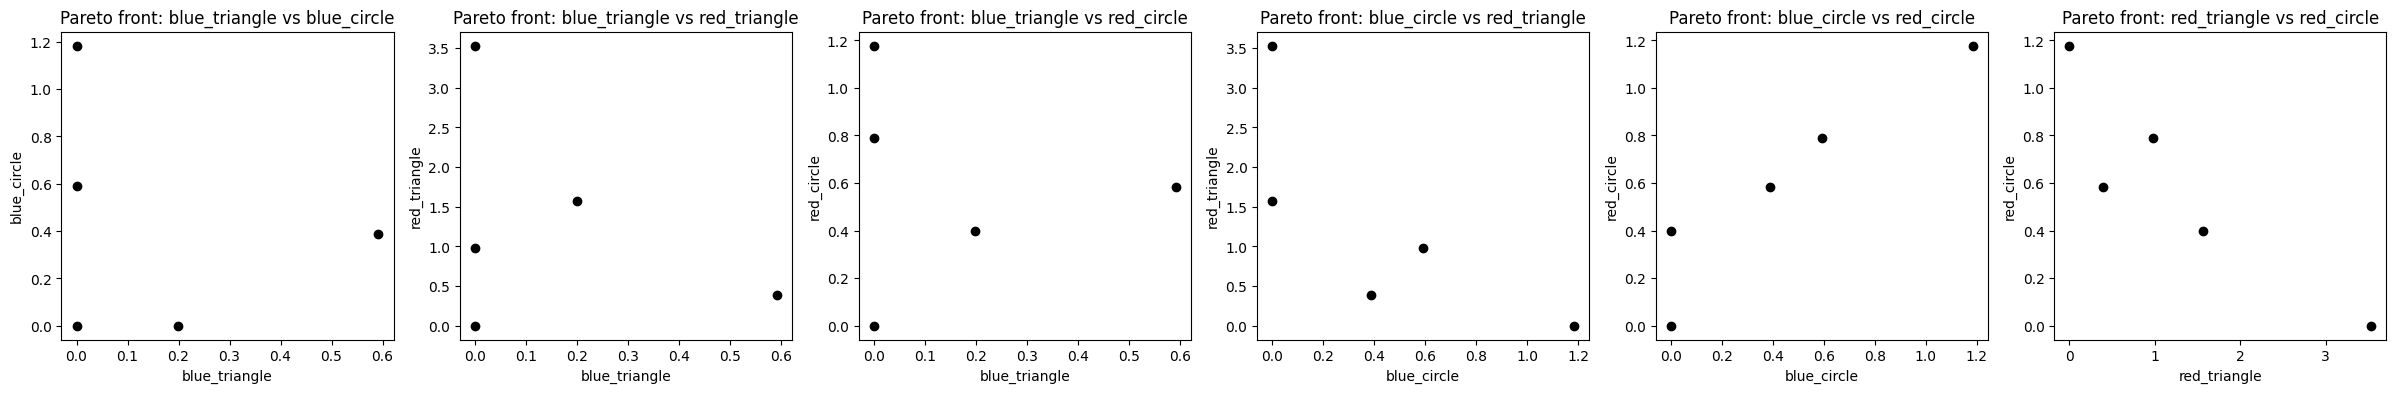

charts/SPS,█▄▃▃▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
eval/cardinality,▁▅▆█
eval/eum,▁███
eval/hypervolume,▁▄▄█
eval_0/discounted_vec_0,█▃▂▇▂▁▁▁▆▁▂▁▁▁▁▁▁▁▁▁▁
eval_0/discounted_vec_1,▃▃▁▁▂▄▆▇▆█▆▅▆▄▇▁▁▂▁▂▁
eval_0/discounted_vec_2,▁
eval_0/discounted_vec_3,▁
eval_0/scalarized_discounted_return,▃▃▁▁▂▄▆▇▆█▆▅▆▄▇▁▁▂▁▂▁
eval_0/scalarized_return,▃▃▁▁▂▅▆▇▆█▆▅▆▄▇▁▁▂▁▂▁
+79,...


Weight sweep: 100%|██████████| 10/10 [1:40:56<00:00, 605.65s/it]


{0.0: array([[0.0796    , 2.71360173],
        [0.74849345, 2.35226719],
        [0.19722482, 2.44720907],
        [1.61519099, 1.05782852]]),
 0.1111111111111111: array([[0.78129874, 0.88219096],
        [0.25842842, 2.39398244],
        [0.31646568, 2.29251411],
        [0.17618222, 2.45462657],
        [2.23660699, 0.66857497]]),
 0.2222222222222222: array([[0.95813418, 0.40188956],
        [0.03095556, 2.1866993 ],
        [0.79240605, 1.55931134],
        [0.34490548, 2.09344319],
        [1.96900562, 0.34762589]]),
 0.3333333333333333: array([[0.19571304, 1.77931982],
        [0.09102485, 1.83846945],
        [0.27537443, 1.5441526 ],
        [1.0475766 , 1.2446087 ]]),
 0.4444444444444444: array([[1.08772268, 0.42791373],
        [0.14426785, 1.57108285],
        [0.82919811, 0.77895137],
        [0.4284461 , 0.81102312],
        [0.34544392, 1.39707888],
        [0.93709401, 0.47012415]]),
 0.5555555555555556: array([[0.08347275, 1.53451583],
        [0.94998391, 0.3151497 ],
 

In [2]:
# train on weighted scalarization between triangle and circle
from tqdm.auto import tqdm

TOTAL_TIMESTEPS = int(1e5)
all_fronts = {}

weights = np.linspace(0.0, 1.0, 10)
for i, w_triangle in enumerate(tqdm(weights, desc="Weight sweep")):
    w_circle = 1.0 - w_triangle
    weight_vec = np.array([w_triangle, w_circle], dtype=np.float32)

    env = CombineWrapper(
        gym.wrappers.TimeLimit(gym.make("my-four-room-v0"), max_episode_steps=MAX_EPISODE_LENGTH),
        weight_vec,
    )
    eval_env = CombineWrapper(
        gym.wrappers.TimeLimit(gym.make("my-four-room-v0"), max_episode_steps=MAX_EPISODE_LENGTH),
        weight_vec,
    )

    agent = MORLD(
        env=env,
        scalarization_method="ws",
        evaluation_mode="ser",
        policy_name="MOSACDiscrete",
        experiment_name=EXPERIMENT_NAME + f"_w{w_triangle:.2f}:{w_circle:.2f}"
    )

    agent.train(
        total_timesteps=TOTAL_TIMESTEPS,
        eval_env=eval_env,
        ref_point=np.array([0, 0]),
    )

    all_fronts[float(w_triangle)] = np.array(agent.archive.evaluations)
    visualize_front_general(
        agent.archive.evaluations,
        columns=["blue_interp", "red_interp"],
    )

    eval_full_four_room(agent)
    agent.close_wandb()

# Optional: inspect all fronts by weight
all_fronts
